# Softmax CNN Face Classification Model (Using TensorFlow/Keras)

This notebook trains and evaluates a convolutional neural network with class folders per identity.

## Expected dataset layout (for Google Colab)

- `Face Recognition 1.0.v1i.folder/train/<class_name>/*.jpg`
- `Face Recognition 1.0.v1i.folder/valid/<class_name>/*.jpg`
- `Face Recognition 1.0.v1i.folder/test/<class_name>/*.jpg`

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# If needed on a local setup, install dependencies
# Uncomment and run the next line once.
# %pip install -U tensorflow keras matplotlib seaborn pandas scikit-learn pillow

from pathlib import Path
import random
import shutil
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array

sns.set_theme(style="whitegrid")
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully.
TensorFlow version: 2.20.0


In [4]:
# Configuration
DATA_ROOT = Path("/content/drive/MyDrive/Face Recognition 1.0.v1i.folder")
SPLITS = ["train", "valid", "test"]

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 25
PATIENCE = 5

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data root: {DATA_ROOT.resolve()}")
print(f"Output dir: {OUTPUT_DIR.resolve()}")

Data root: /content/drive/MyDrive/Face Recognition 1.0.v1i.folder
Output dir: /content/outputs


In [5]:
# Validate dataset structure and count images per class/split.
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

for split in SPLITS:
    split_path = DATA_ROOT / split
    assert split_path.exists(), f"Missing split folder: {split_path}"

train_classes = sorted([p.name for p in (DATA_ROOT / "train").iterdir() if p.is_dir()])
assert train_classes, "No class folders found in train split."

records = []
for split in SPLITS:
    split_path = DATA_ROOT / split
    split_classes = sorted([p.name for p in split_path.iterdir() if p.is_dir()])
    missing = set(train_classes) - set(split_classes)
    extra = set(split_classes) - set(train_classes)
    if missing:
        print(f"Warning: {split} missing classes: {sorted(missing)}")
    if extra:
        print(f"Warning: {split} has extra classes: {sorted(extra)}")

    for cls in split_classes:
        cls_path = split_path / cls
        count = sum(1 for fp in cls_path.rglob("*") if fp.suffix.lower() in image_exts)
        records.append({"split": split, "class": cls, "images": count})

counts_df = pd.DataFrame(records).sort_values(["split", "class"]).reset_index(drop=True)
print("Class folders detected:", train_classes)
counts_df

Class folders detected: ['Andre', 'Federico', 'Micaela', 'Nahuel', 'Ramiro']


,split,class,images
0,test,Andre,88
1,test,Federico,77
2,test,Micaela,87
3,test,Nahuel,78
4,test,Ramiro,94
5,train,Andre,531
6,train,Federico,507
7,train,Micaela,516
8,train,Nahuel,504
9,train,Ramiro,507


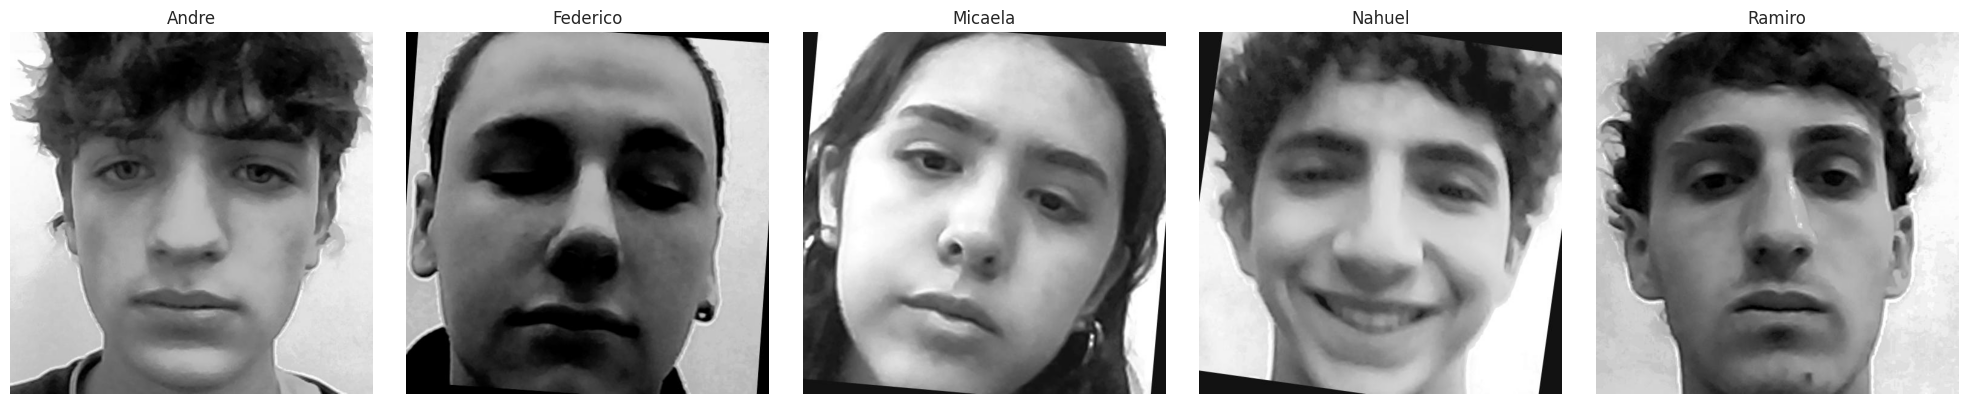

In [5]:
# Quick visual sanity check: one random image per class from train split.
fig, axes = plt.subplots(1, len(train_classes), figsize=(4 * len(train_classes), 4))
if len(train_classes) == 1:
    axes = [axes]

for ax, cls in zip(axes, train_classes):
    cls_path = DATA_ROOT / "train" / cls
    images = [fp for fp in cls_path.rglob("*") if fp.suffix.lower() in image_exts]
    if not images:
        ax.set_title(f"{cls}\n(no image)")
        ax.axis("off")
        continue
    sample_path = random.choice(images)
    img = Image.open(sample_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Load training dataset and determine number of classes.
train_ds = keras.utils.image_dataset_from_directory(
    DATA_ROOT / "train",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

val_ds = keras.utils.image_dataset_from_directory(
    DATA_ROOT / "valid",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

test_ds = keras.utils.image_dataset_from_directory(
    DATA_ROOT / "test",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

num_classes = len(train_ds.class_names)
class_names = sorted(train_ds.class_names)

print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Found 2565 files belonging to 5 classes.
Found 430 files belonging to 5 classes.
Found 424 files belonging to 5 classes.
Number of classes: 5
Class names: ['Andre', 'Federico', 'Micaela', 'Nahuel', 'Ramiro']


In [8]:
# Build softmax CNN model.
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Conv2D(256, 3, activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax"),  # Softmax output for multi-class classification
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,083,525 (99.50 MB)

 Trainable params: 26,082,565 (99.50 MB)

 Non-trainable params: 960 (3.75 KB)

None


In [8]:
# Train the CNN model.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1,
)

# Save the trained model.
model_path = OUTPUT_DIR / "cnn_model.keras"
model.save(model_path)
print(f"Model saved to: {model_path.resolve()}")

Epoch 1/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 499s 3s/step - accuracy: 0.9415 - loss: 2.6083 - val_accuracy: 0.5419 - val_loss: 13.6990
Epoch 2/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.9836 - loss: 0.8020 - val_accuracy: 0.9977 - val_loss: 0.0222
Epoch 3/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/step - accuracy: 0.9793 - loss: 1.3214 - val_accuracy: 0.9930 - val_loss: 0.1621
Epoch 4/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.9918 - loss: 0.5316 - val_accuracy: 1.0000 - val_loss: 2.7723e-10
Epoch 5/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/step - accuracy: 0.9926 - loss: 0.4111 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.9938 - loss: 0.3979 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.9942 - loss: 0.4481 - val_accuracy: 0.9767 - val_loss: 3.9668
Epoch 8/25
161/161 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.9965 - los

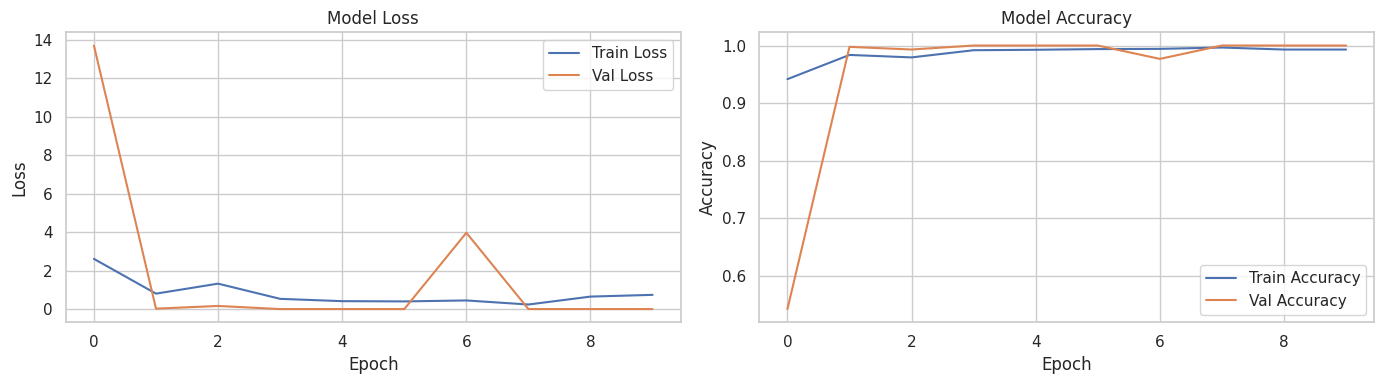

Final training accuracy: 0.9930
Final validation accuracy: 1.0000


In [9]:
# Plot training history.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Model Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history["accuracy"], label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Model Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [10]:
# Generate test predictions and build results table.
test_records = []

test_root = DATA_ROOT / "test"
for cls_dir in sorted([p for p in test_root.iterdir() if p.is_dir()]):
    true_label = cls_dir.name
    image_paths = [fp for fp in cls_dir.rglob("*") if fp.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}]

    for image_path in image_paths:
        # Load and preprocess image
        img = load_img(str(image_path), target_size=(IMG_SIZE, IMG_SIZE))
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0  # Normalize

        # Predict
        probs = model.predict(img_array, verbose=0)[0]
        pred_idx = np.argmax(probs)
        pred_label = class_names[pred_idx]
        conf = float(probs[pred_idx])

        test_records.append(
            {
                "image_path": str(image_path),
                "true_label": true_label,
                "pred_label": pred_label,
                "confidence": conf,
            }
        )

pred_df = pd.DataFrame(test_records)
print(f"Test predictions collected: {len(pred_df)} rows")
pred_df.head()

Test predictions collected: 424 rows


,image_path,true_label,pred_label,confidence
0,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,Micaela,1.0
1,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,Micaela,1.0
2,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,Micaela,1.0
3,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,Micaela,1.0
4,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,Micaela,1.0


In [11]:
# Classification report and per-class metrics.
label_order = sorted(pred_df["true_label"].unique())

report_dict = classification_report(
    pred_df["true_label"],
    pred_df["pred_label"],
    labels=label_order,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T
report_df

,precision,recall,f1-score,support
Andre,0.000000,0.000000,0.000000,88.000000
Federico,0.000000,0.000000,0.000000,77.000000
Micaela,0.205189,1.000000,0.340509,87.000000
Nahuel,0.000000,0.000000,0.000000,78.000000
Ramiro,0.000000,0.000000,0.000000,94.000000
accuracy,0.205189,0.205189,0.205189,0.205189
macro avg,0.041038,0.200000,0.068102,424.000000
weighted avg,0.042102,0.205189,0.069869,424.000000


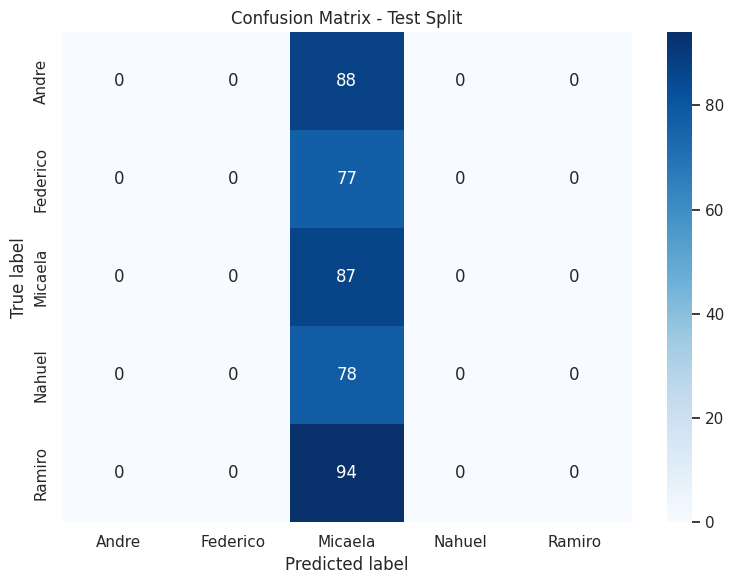

Saved confusion matrix: /content/outputs/confusion_matrix.png


In [12]:
# Confusion matrix visualization.
cm = confusion_matrix(pred_df["true_label"], pred_df["pred_label"], labels=label_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Test Split")
plt.tight_layout()

cm_path = OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150)
plt.show()

print(f"Saved confusion matrix: {cm_path.resolve()}")

In [13]:
# Save prediction and metrics artifacts.
pred_csv_path = OUTPUT_DIR / "test_predictions.csv"
report_csv_path = OUTPUT_DIR / "classification_report.csv"

pred_df.to_csv(pred_csv_path, index=False)
report_df.to_csv(report_csv_path)

print(f"Saved predictions: {pred_csv_path.resolve()}")
print(f"Saved report: {report_csv_path.resolve()}")

Saved predictions: /content/outputs/test_predictions.csv
Saved report: /content/outputs/classification_report.csv


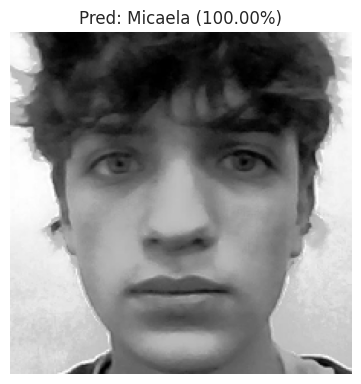

{'image_path': '/content/drive/MyDrive/Face Recognition 1.0.v1i.folder/test/Andre/Andre_57_jpeg.rf.805c71dff614ab1a15e8d97979e50337.jpg',
 'pred_label': 'Micaela',
 'confidence': 1.0}

In [14]:
# Single-image inference demo.
def show_prediction(image_path: Path, clf_model: keras.Model):
    img = load_img(str(image_path), target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize

    probs = clf_model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = class_names[pred_idx]
    conf = float(probs[pred_idx])

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Pred: {pred_label} ({conf:.2%})")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return {"image_path": str(image_path), "pred_label": pred_label, "confidence": conf}

sample_image = Path(pred_df.iloc[0]["image_path"])
sample_pred_info = show_prediction(sample_image, model)
sample_pred_info

In [15]:
# Batch inference using Keras dataset.
batch_preds = model.predict(test_ds, verbose=0)

batch_summary = []
image_paths_all = []

# Collect all image paths from test set
for cls_dir in sorted([p for p in (DATA_ROOT / "test").iterdir() if p.is_dir()]):
    image_paths_all.extend(sorted([fp for fp in cls_dir.rglob("*") if fp.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}]))

# Build batch summary from predictions
for i, (image_path, pred_probs) in enumerate(zip(image_paths_all[:10], batch_preds[:10])):
    pred_idx = np.argmax(pred_probs)
    batch_summary.append(
        {
            "image_path": str(image_path),
            "pred_label": class_names[pred_idx],
            "confidence": float(pred_probs[pred_idx]),
        }
    )

print(f"Batch predictions generated for {len(batch_preds)} items from test set")
pd.DataFrame(batch_summary)

Batch predictions generated for 424 items from test set


,image_path,pred_label,confidence
0,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0
1,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0
2,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0
3,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0
4,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0
5,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0
6,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0
7,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0
8,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0
9,/content/drive/MyDrive/Face Recognition 1.0.v1...,Andre,1.0


In [16]:
# Save class names for reference and reproducibility.
class_names_path = OUTPUT_DIR / "class_names.pkl"
with open(class_names_path, "wb") as f:
    pickle.dump(class_names, f)

print(f"Model saved: {model_path.resolve()}")
print(f"Class names saved: {class_names_path.resolve()}")

Model saved: /content/outputs/cnn_model.keras
Class names saved: /content/outputs/class_names.pkl


In [17]:
new_output_dir = DATA_ROOT / OUTPUT_DIR.name
if new_output_dir.exists():
    print(f"Destination directory already exists: {new_output_dir}. Skipping move.")
else:
    shutil.move(OUTPUT_DIR, new_output_dir)
    OUTPUT_DIR = new_output_dir
    print(f"Moved outputs folder to: {OUTPUT_DIR.resolve()}")

Destination directory already exists: /content/drive/MyDrive/Face Recognition 1.0.v1i.folder/outputs. Skipping move.


## How to rerun

1. Run cells top-to-bottom in order.
2. If dependencies are missing, uncomment the `%pip install` line in the setup cell and run it once.
3. Training runtime depends on hardware (CPU may take significantly longer than GPU).
4. The model uses early stopping with patience of 5 epochs on validation loss.
5. Main generated artifacts:
   - Trained model: `outputs/cnn_model.keras`
   - Class names: `outputs/class_names.pkl`
   - Test predictions CSV: `outputs/test_predictions.csv`
   - Classification report CSV: `outputs/classification_report.csv`
   - Confusion matrix image: `outputs/confusion_matrix.png`
   - Training history plot: Displayed in notebook